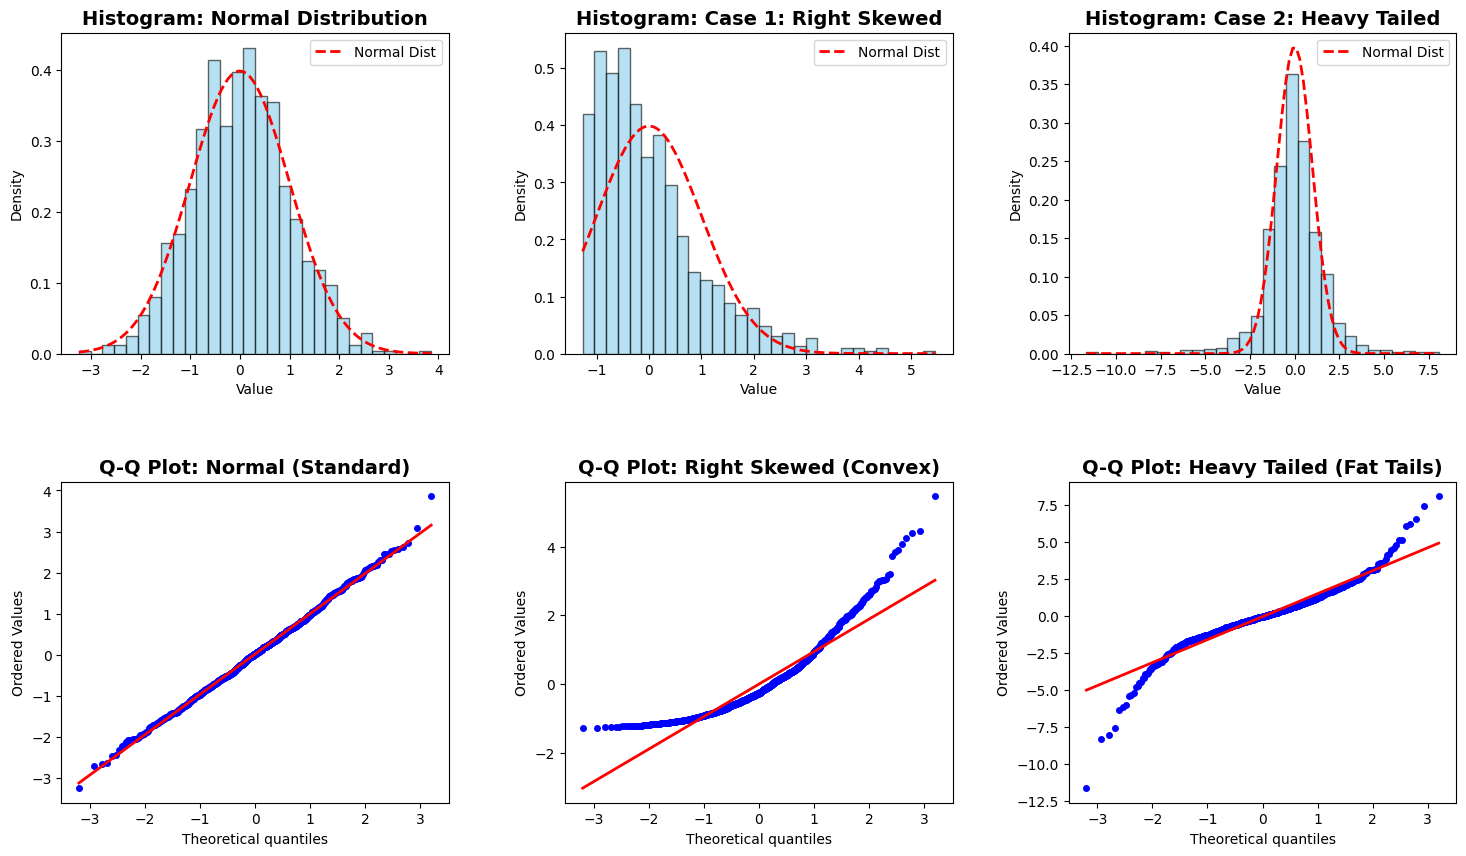

In [2]:
'''
[코드 설명]
1. 세 가지 데이터셋을 생성합니다:
   - Normal: 기준이 되는 정규분포 (비교용)
   - Case 1 (Right Skewed): 오른쪽으로 꼬리가 긴 카이제곱 분포 (비대칭)
   - Case 2 (Heavy Tailed): 양쪽 꼬리가 두꺼운 t-분포 (자유도 3)

2. 2행 3열의 그래프를 그립니다:
   - 위쪽 행: 데이터의 실제 모양(Histogram)
   - 아래쪽 행: 정규성 검정을 위한 Q-Q Plot

3. 시각적 비교를 통해 이론적 분위수(X축)와 실제 데이터(Y축)의 관계를 확인합니다.
'''

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. 데이터 생성 설정
np.random.seed(42) # 재현성을 위해 시드 고정
n_samples = 1000   # 샘플 개수

# (0) 기준: 정규분포 (Standard Normal)
data_normal = np.random.normal(loc=0, scale=1, size=n_samples)

# (1) Case 1: 오른쪽 꼬리가 긴 분포 (Right Skewed)
# 카이제곱 분포(df=3)를 사용하여 오른쪽으로 길게 늘어진 데이터를 만듭니다.
# 비교를 위해 표준화(Standardization)를 수행하여 스케일을 맞춥니다.
raw_case1 = np.random.chisquare(df=3, size=n_samples)
data_case1 = (raw_case1 - np.mean(raw_case1)) / np.std(raw_case1)

# (2) Case 2: 꼬리가 두꺼운 분포 (Heavy Tailed)
# t-분포(df=3)는 정규분포와 모양은 비슷하지만 양쪽 꼬리가 훨씬 두껍습니다.
data_case2 = np.random.standard_t(df=3, size=n_samples)

# 2. 그래프 그리기 (2행 3열)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 텍스트 스타일 설정
title_font = {'fontsize': 14, 'fontweight': 'bold'}

# --- 함수: 히스토그램과 Q-Q Plot 그리기 ---
def plot_analysis(data, col_idx, title_hist, title_qq):
    # 1) 히스토그램 (분포 모양 확인)
    ax_hist = axes[0, col_idx]
    ax_hist.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')
    ax_hist.set_title(f"Histogram: {title_hist}", **title_font)
    ax_hist.set_xlabel("Value")
    ax_hist.set_ylabel("Density")
    
    # 정규분포 곡선 겹쳐 그리기 (비교용 빨간 점선)
    x = np.linspace(min(data), max(data), 100)
    ax_hist.plot(x, stats.norm.pdf(x, 0, 1), 'r--', lw=2, label='Normal Dist')
    ax_hist.legend()

    # 2) Q-Q Plot (정규성 검정)
    ax_qq = axes[1, col_idx]
    stats.probplot(data, dist="norm", plot=ax_qq)
    ax_qq.set_title(f"Q-Q Plot: {title_qq}", **title_font)
    ax_qq.get_lines()[0].set_markerfacecolor('blue') # 데이터 점
    ax_qq.get_lines()[0].set_markersize(4.0)
    ax_qq.get_lines()[1].set_color('red')     # 기준선 (정규분포일 때)
    ax_qq.get_lines()[1].set_linewidth(2.0)

# --- 실행 ---
# Column 0: 정규분포 (기준)
plot_analysis(data_normal, 0, "Normal Distribution", "Normal (Standard)")

# Column 1: Case 1 (Right Skewed)
plot_analysis(data_case1, 1, "Case 1: Right Skewed", "Right Skewed (Convex)")

# Column 2: Case 2 (Heavy Tailed)
plot_analysis(data_case2, 2, "Case 2: Heavy Tailed", "Heavy Tailed (Fat Tails)")

plt.show()